# Exploratory Data Analysis - MIT-BIH Arrhythmia Database

CRISP-DM stage 2 (**Data Understanding**). Covers report sections 2.1-2.5.

Prerequisites (from the repo root):
```
python src/download_data.py
python src/prepare_data.py
```
All figures are written to `results/figures/eda_*.png` for use in the report.

**Leakage note:** waveform/morphology analysis uses **DS1 only**. DS2 is only inspected through
header information and class counts, which does not influence modeling decisions.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb
from matplotlib.colors import LogNorm
from scipy import signal as sps

from config import class_names, load_config, resolve, split_records, symbol_to_class
from noise import load_noise, scaled_noise
from prepare_data import load_record, preprocess_signal

cfg = load_config("configs/data.yaml")
MITDB, NSTDB = resolve(cfg["paths"]["mitdb_dir"]), resolve(cfg["paths"]["nstdb_dir"])
STATS = resolve(cfg["paths"]["stats_dir"])
FIG = resolve("results/figures")
FIG.mkdir(parents=True, exist_ok=True)

CLASSES, MAP, SPLITS = class_names(cfg), symbol_to_class(cfg), split_records(cfg)
DS1, DS2 = sorted(cfg["splits"]["ds1"]), sorted(cfg["splits"]["ds2"])
ALL = sorted(DS1 + DS2)
FS, LEAD = cfg["signal"]["fs"], cfg["signal"]["lead"]
PRE = cfg["window"]["pre_samples"]

# Categorical colours in fixed slot order (identity), recessive grid and axes.
CLASS_COLORS = dict(zip(CLASSES, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))
SPLIT_COLORS = {"train": "#2a78d6", "val": "#eb6834", "test": "#1baf7a"}
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.titlesize": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "legend.frameon": False,
})


def save(fig, name):
    fig.savefig(FIG / f"eda_{name}.png", dpi=200, bbox_inches="tight")


record_stats = pd.read_csv(STATS / "record_stats.csv")
split_summary = pd.read_csv(STATS / "split_summary.csv")
annotation_mapping = pd.read_csv(STATS / "annotation_mapping.csv")

## 2.1 Dataset description

In [2]:
rows = []
for r in ALL:
    h = wfdb.rdheader(str(MITDB / str(r)))
    tokens = h.comments[0].split() if h.comments else []
    rows.append({
        "record": r, "set": "DS1" if r in DS1 else "DS2", "fs_Hz": h.fs, "n_channels": h.n_sig,
        "n_samples": h.sig_len, "duration_min": round(h.sig_len / h.fs / 60, 2),
        "channel_0": h.sig_name[0], "channel_1": h.sig_name[1],
        "age": tokens[0] if tokens else "", "sex": tokens[1] if len(tokens) > 1 else "",
    })
headers = pd.DataFrame(rows)
db_records = sorted(int(p.stem) for p in MITDB.glob("*.hea") if p.stem.isdigit())

print(f"Records in database: {len(db_records)} | used (DS1 + DS2): {len(ALL)} | not used: {sorted(set(db_records) - set(ALL))}")
print(f"Sampling frequencies: {headers.fs_Hz.unique()} Hz | channels per record: {headers.n_channels.unique()}")
print(f"Duration per record: {headers.duration_min.min()}-{headers.duration_min.max()} min "
      f"| total used: {headers.duration_min.sum() / 60:.1f} h")
print("Lead pairs:", (headers.channel_0 + " / " + headers.channel_1).value_counts().to_dict())
print("Annotations in used records (beat and non-beat):", int(annotation_mapping.total.sum()))
headers

Records in database: 48 | used (DS1 + DS2): 44 | not used: [102, 104, 107, 217]
Sampling frequencies: [360] Hz | channels per record: [2]
Duration per record: 30.09-30.09 min | total used: 22.1 h
Lead pairs: {'MLII / V1': 38, 'MLII / V5': 2, 'MLII / V2': 2, 'V5 / MLII': 1, 'MLII / V4': 1}
Annotations in used records (beat and non-beat): 103650


,record,set,fs_Hz,n_channels,n_samples,duration_min,channel_0,channel_1,age,sex
0,100,DS2,360,2,650000,30.09,MLII,V5,69,M
1,101,DS1,360,2,650000,30.09,MLII,V1,75,F
2,103,DS2,360,2,650000,30.09,MLII,V2,-1,M
3,105,DS2,360,2,650000,30.09,MLII,V1,73,F
4,106,DS1,360,2,650000,30.09,MLII,V1,24,F
5,108,DS1,360,2,650000,30.09,MLII,V1,87,F
6,109,DS1,360,2,650000,30.09,MLII,V1,64,M
7,111,DS2,360,2,650000,30.09,MLII,V1,47,F
8,112,DS1,360,2,650000,30.09,MLII,V1,54,M
9,113,DS2,360,2,650000,30.09,MLII,V1,24,F


## 2.2 Target classes

In [3]:
display(annotation_mapping)
display(split_summary)

,symbol,description,final_class,reason,train,val,test,total
0,F,Fusion of ventricular and normal beat,F,NaN,385,29,388,802
1,N,Normal beat,N,NaN,31854,6220,36415,74489
2,L,Left bundle branch block beat,N,NaN,1457,2490,4123,8070
3,R,Right bundle branch block beat,N,NaN,3779,0,3473,7252
4,j,Nodal (junctional) escape beat,N,NaN,6,10,213,229
5,e,Atrial escape beat,N,NaN,0,16,0,16
6,A,Atrial premature contraction,S,NaN,705,105,1736,2546
7,a,Aberrated atrial premature beat,S,NaN,2,98,50,150
8,J,Nodal (junctional) premature beat,S,NaN,31,1,51,83
9,S,Premature or ectopic supraventricular beat,S,NaN,2,0,0,2


,split,n_records,records,N,S,V,F,total
0,train,18,101 106 108 112 114 115 116 118 119 122 124 20...,37096,740,3006,385,41227
1,val,4,109 201 205 223,8736,204,780,29,9749
2,test,22,100 103 105 111 113 117 121 123 200 202 210 21...,44224,1837,3219,388,49668
3,all,44,NaN,90056,2781,7005,802,100644


## 2.3 Exploratory data analysis
### Example ECG signal

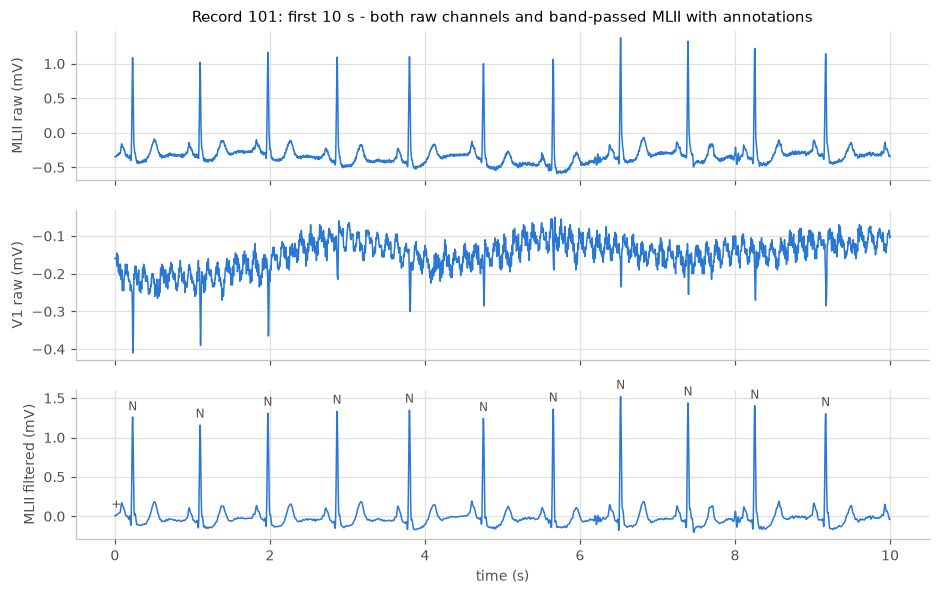

In [4]:
r = DS1[0]
rec = wfdb.rdrecord(str(MITDB / str(r)))
ann = wfdb.rdann(str(MITDB / str(r)), "atr")
seg = slice(0, 10 * FS)
t = np.arange(seg.start, seg.stop) / FS
lead_idx = rec.sig_name.index(LEAD)
x_filt = preprocess_signal(rec.p_signal[:, lead_idx], FS, cfg)

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for ax, ch in zip(axes[:2], range(rec.n_sig)):
    ax.plot(t, rec.p_signal[seg, ch], color=CLASS_COLORS["N"], lw=1)
    ax.set_ylabel(f"{rec.sig_name[ch]} raw (mV)")
axes[2].plot(t, x_filt[seg], color=CLASS_COLORS["N"], lw=1)
m = ann.sample < seg.stop
for s, sym in zip(ann.sample[m], np.array(ann.symbol)[m]):
    axes[2].annotate(sym, (s / FS, x_filt[s]), xytext=(0, 5), textcoords="offset points",
                     ha="center", fontsize=8, color=INK2)
axes[2].set_ylabel(f"{LEAD} filtered (mV)")
axes[2].set_xlabel("time (s)")
axes[0].set_title(f"Record {r}: first 10 s - both raw channels and band-passed {LEAD} with annotations")
save(fig, "example_signal")

### Example heartbeat from each class (DS1)

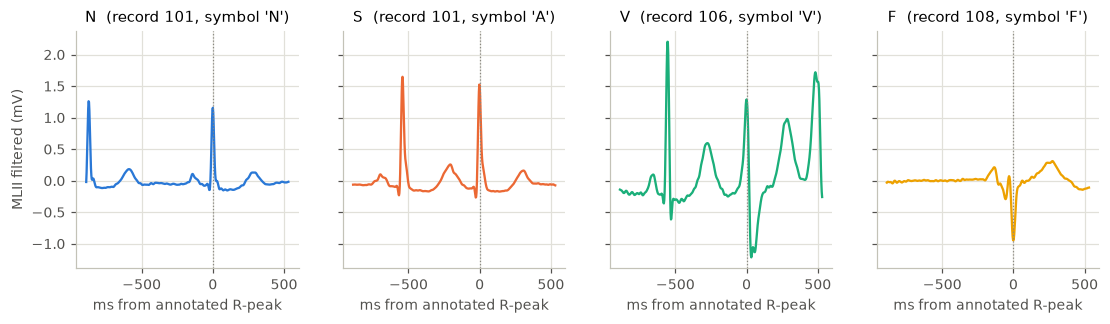

In [5]:
# One raw example per class (first occurrence in DS1), band-pass filtered, in mV.
examples = {}
for r in DS1:
    ann = wfdb.rdann(str(MITDB / str(r)), "atr")
    for s, sym in zip(ann.sample, ann.symbol):
        c = CLASSES[MAP[sym]] if sym in MAP else None
        if c and c not in examples and s > PRE and s < 649_000:
            examples[c] = (r, s, sym)
    if len(examples) == len(CLASSES):
        break

L = PRE + cfg["window"]["post_samples"]
t_ms = (np.arange(L) - PRE) / FS * 1000
fig, axes = plt.subplots(1, 4, figsize=(12, 2.8), sharey=True)
for ax, c in zip(axes, CLASSES):
    r, s, sym = examples[c]
    x, fs, _, _ = load_record(MITDB, r, LEAD)
    xf = preprocess_signal(x, fs, cfg)
    ax.plot(t_ms, xf[s - PRE:s + L - PRE], color=CLASS_COLORS[c], lw=1.5)
    ax.axvline(0, color=MUTED, lw=0.8, ls=":")
    ax.set_title(f"{c}  (record {r}, symbol '{sym}')")
    ax.set_xlabel("ms from annotated R-peak")
axes[0].set_ylabel(f"{LEAD} filtered (mV)")
save(fig, "example_beats_raw")

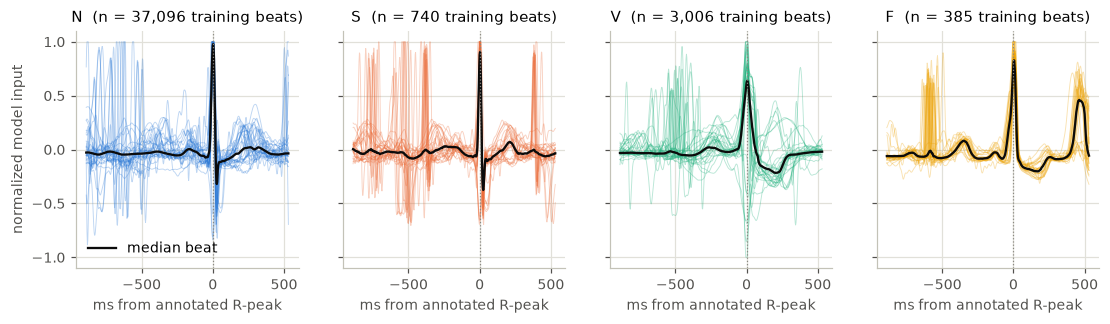

In [6]:
train = np.load(resolve(cfg["paths"]["processed_dir"]) / "train.npz")
X, y = train["X"][:, 0], train["y"]
rng = np.random.default_rng(cfg["seed"])

fig, axes = plt.subplots(1, 4, figsize=(12, 2.8), sharey=True)
for k, (ax, c) in enumerate(zip(axes, CLASSES)):
    idx = np.flatnonzero(y == k)
    for i in rng.choice(idx, min(30, len(idx)), replace=False):
        ax.plot(t_ms, X[i], color=CLASS_COLORS[c], lw=0.6, alpha=0.3)
    ax.plot(t_ms, np.median(X[idx], axis=0), color=INK, lw=1.5, label="median beat")
    ax.axvline(0, color=MUTED, lw=0.8, ls=":")
    ax.set_title(f"{c}  (n = {len(idx):,} training beats)")
    ax.set_xlabel("ms from annotated R-peak")
axes[0].set_ylabel("normalized model input")
axes[0].legend(loc="lower left")
save(fig, "example_beats_normalized")

### Class distribution

Share of all beats: {'N': 0.8948, 'S': 0.0276, 'V': 0.0696, 'F': 0.008}
Imbalance ratio N : minority class = {'S': np.float64(32.4), 'V': np.float64(12.9), 'F': np.float64(112.3)}


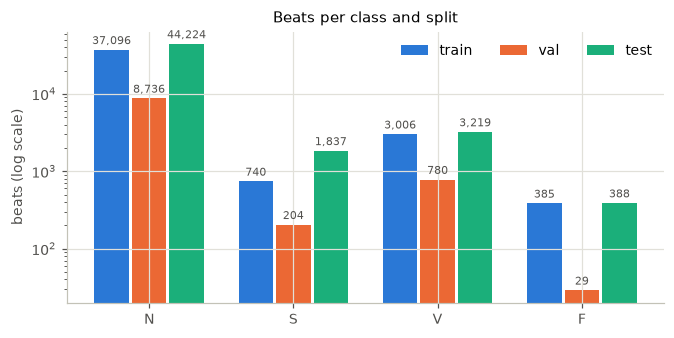

In [7]:
s = split_summary.set_index("split").loc[["train", "val", "test"], CLASSES]
fig, ax = plt.subplots(figsize=(7, 3.2))
width = 0.26
for j, split in enumerate(s.index):
    xs = np.arange(len(CLASSES)) + (j - 1) * width
    bars = ax.bar(xs, s.loc[split], width - 0.02, color=SPLIT_COLORS[split], label=split)
    ax.bar_label(bars, labels=[f"{v:,}" for v in s.loc[split]], fontsize=7, color=INK2, padding=2)
ax.set_yscale("log")
ax.set_xticks(range(len(CLASSES)), CLASSES)
ax.set_ylabel("beats (log scale)")
ax.set_title("Beats per class and split")
ax.legend(ncols=3, loc="upper right")
save(fig, "class_distribution")

tot = split_summary.set_index("split").loc["all", CLASSES]
print("Share of all beats:", (tot / tot.sum()).round(4).to_dict())
print("Imbalance ratio N : minority class =", {c: round(tot["N"] / tot[c], 1) for c in CLASSES[1:]})

### Subject / record distribution

Records containing each class: {'N': 44, 'S': 32, 'V': 33, 'F': 17}
Share of each class contributed by its largest record:
  N: record 215 (train) holds 4% of all N beats
  S: record 232 (test) holds 50% of all S beats
  V: record 208 (train) holds 14% of all V beats
  F: record 208 (train) holds 46% of all F beats


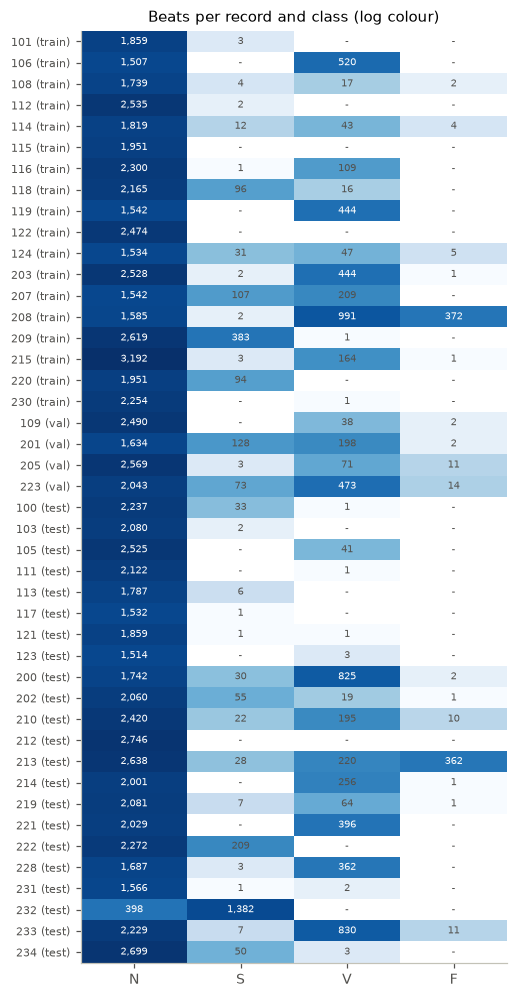

In [8]:
rs = record_stats.assign(order=record_stats.split.map({"train": 0, "val": 1, "test": 2})).sort_values(["order", "record"])
counts = rs[CLASSES].to_numpy()
fig, ax = plt.subplots(figsize=(5, 11))
ax.imshow(np.where(counts > 0, counts, np.nan), aspect="auto", cmap="Blues", norm=LogNorm(1, counts.max()))
for i in range(counts.shape[0]):
    for j in range(counts.shape[1]):
        v = counts[i, j]
        ax.text(j, i, f"{v:,}" if v else "-", ha="center", va="center", fontsize=6.5,
                color="white" if v > 300 else INK2)
ax.set_xticks(range(len(CLASSES)), CLASSES)
ax.set_yticks(range(len(rs)), [f"{r} ({s})" for r, s in zip(rs.record, rs.split)], fontsize=7)
ax.grid(False)
ax.set_title("Beats per record and class (log colour)")
save(fig, "record_distribution")

print("Records containing each class:", {c: int((rs[c] > 0).sum()) for c in CLASSES})
print("Share of each class contributed by its largest record:")
for c in CLASSES:
    top = rs.loc[rs[c].idxmax()]
    print(f"  {c}: record {top.record} ({top.split}) holds {top[c] / rs[c].sum():.0%} of all {c} beats")

### Signal amplitude distribution

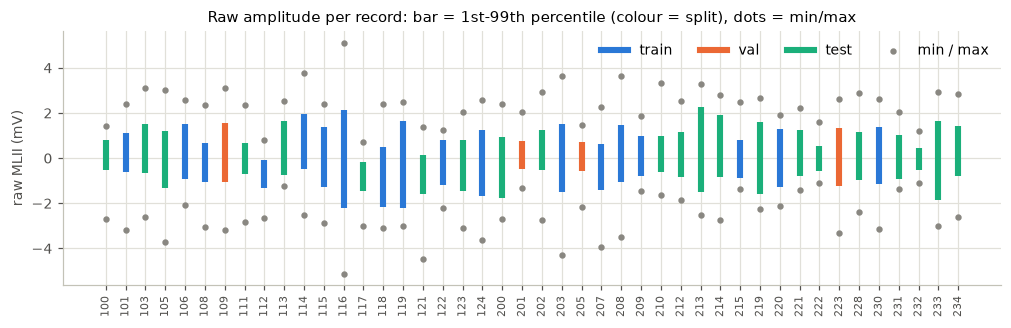

In [9]:
# Per-record raw amplitude range (all used records, header-level statistics from prepare_data.py)
rs = record_stats.sort_values("record")
fig, ax = plt.subplots(figsize=(11, 3))
xs = np.arange(len(rs))
colors = [SPLIT_COLORS[s] for s in rs.split]
ax.vlines(xs, rs.raw_p1_mV, rs.raw_p99_mV, color=colors, lw=4)
extremes = ax.scatter(xs, rs.raw_min_mV, s=10, color=MUTED, zorder=3, label="min / max")
ax.scatter(xs, rs.raw_max_mV, s=10, color=MUTED, zorder=3)
ax.set_xticks(xs, rs.record, rotation=90, fontsize=7)
ax.set_ylabel(f"raw {LEAD} (mV)")
ax.set_title("Raw amplitude per record: bar = 1st-99th percentile (colour = split), dots = min/max")
handles = [plt.Line2D([], [], color=c, lw=4, label=s) for s, c in SPLIT_COLORS.items()]
ax.legend(handles=handles + [extremes], ncols=4, loc="upper right")
save(fig, "amplitude_per_record")

,N,S,V,F
count,45866.000,944.000,3788.000,415.000
mean,1.423,1.048,0.973,1.739
std,0.801,0.945,1.448,0.629
min,-2.146,-1.547,-3.178,-2.327
25%,1.030,0.886,0.335,1.577
50%,1.490,1.304,1.262,1.824
75%,1.931,1.578,1.733,2.097
max,3.749,3.322,4.010,2.742


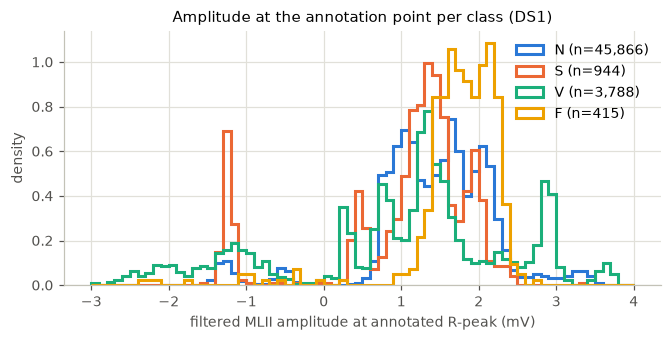

In [10]:
# R-peak amplitude (band-passed) per class - DS1 only
r_amp = {c: [] for c in CLASSES}
filtered_ds1 = {}
for r in DS1:
    x, fs, samples, symbols = load_record(MITDB, r, LEAD)
    xf = preprocess_signal(x, fs, cfg)
    filtered_ds1[r] = (x, xf, samples, symbols)
    for s, sym in zip(samples, symbols):
        if sym in MAP:
            r_amp[CLASSES[MAP[sym]]].append(xf[s])

fig, ax = plt.subplots(figsize=(7, 3))
bins = np.linspace(-3, 4, 71)
for c in CLASSES:
    ax.hist(r_amp[c], bins=bins, density=True, histtype="step", lw=2, color=CLASS_COLORS[c], label=f"{c} (n={len(r_amp[c]):,})")
ax.set_xlabel(f"filtered {LEAD} amplitude at annotated R-peak (mV)")
ax.set_ylabel("density")
ax.set_title("Amplitude at the annotation point per class (DS1)")
ax.legend()
save(fig, "rpeak_amplitude_per_class")
pd.DataFrame({c: pd.Series(v).describe() for c, v in r_amp.items()}).round(3)

### Examples of noisy ECG

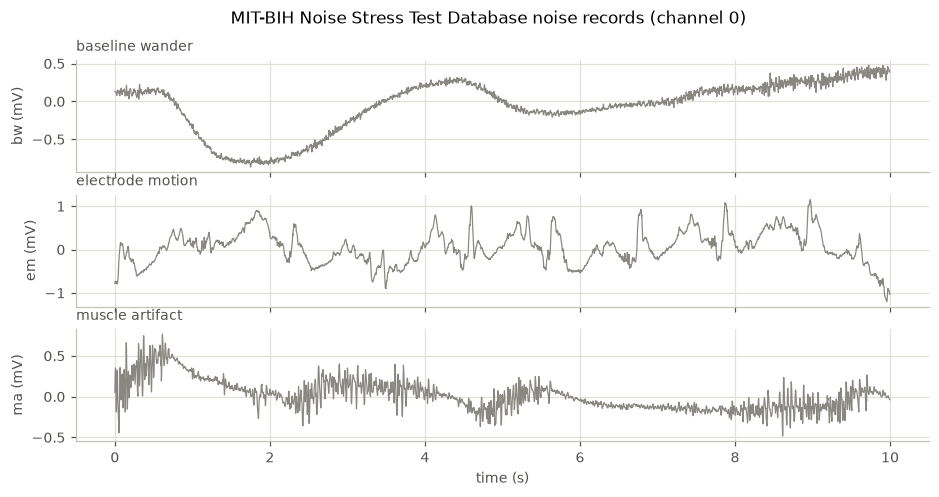

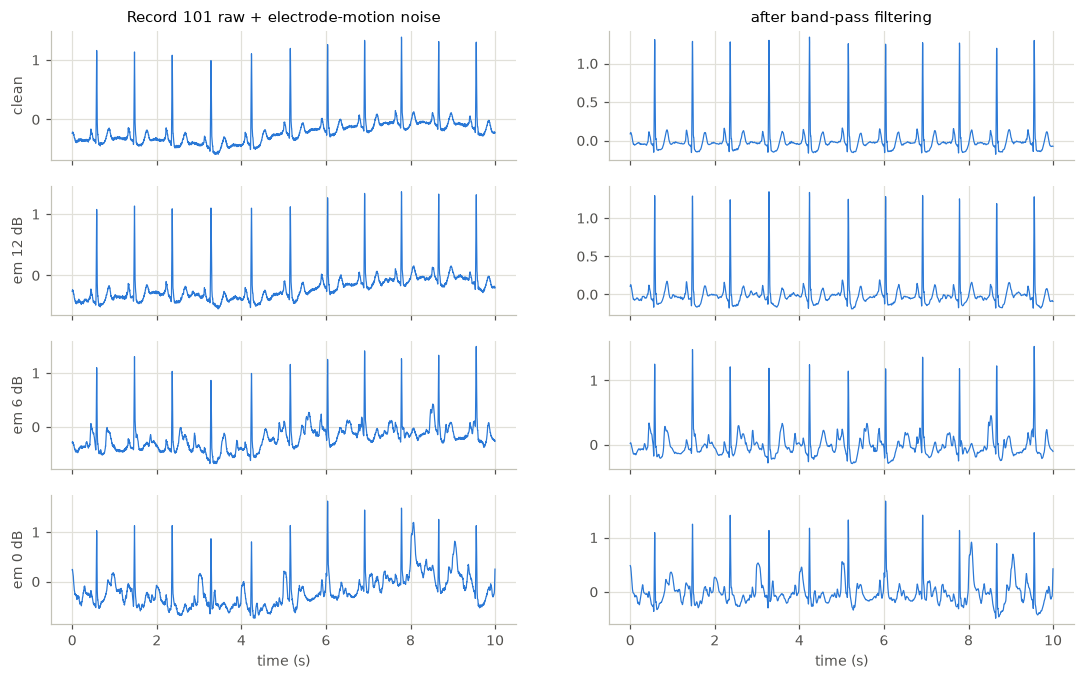

In [11]:
# NSTDB noise types (training part of each noise record only) and a clean DS1 record with added noise
r = DS1[0]
x, xf = filtered_ds1[r][:2]
seg = slice(60 * FS, 70 * FS)
t = np.arange(seg.stop - seg.start) / FS
rng = np.random.default_rng(cfg["seed"])

fig, axes = plt.subplots(3, 1, figsize=(10, 4.5), sharex=True)
for ax, (ntype, desc) in zip(axes, cfg["noise"]["types"].items()):
    n = load_noise(cfg, ntype, part="train")
    ax.plot(t, n[seg], color=MUTED, lw=0.8)
    ax.set_ylabel(f"{ntype} (mV)")
    ax.set_title(desc, loc="left", fontsize=9, color=INK2)
axes[-1].set_xlabel("time (s)")
fig.suptitle("MIT-BIH Noise Stress Test Database noise records (channel 0)")
save(fig, "nstdb_noise")

fig, axes = plt.subplots(4, 2, figsize=(12, 7), sharex=True)
power = xf.var()
em = load_noise(cfg, "em", part="train")
for row, snr in enumerate([None] + cfg["noise"]["snr_db"]):
    noisy = x if snr is None else x + scaled_noise(em, len(x), power, snr, rng)
    label = "clean" if snr is None else f"em {snr} dB"
    axes[row, 0].plot(t, noisy[seg], color=CLASS_COLORS["N"], lw=0.8)
    axes[row, 1].plot(t, preprocess_signal(noisy, FS, cfg)[seg], color=CLASS_COLORS["N"], lw=0.8)
    axes[row, 0].set_ylabel(label)
axes[0, 0].set_title(f"Record {r} raw + electrode-motion noise")
axes[0, 1].set_title("after band-pass filtering")
for ax in axes[-1]:
    ax.set_xlabel("time (s)")
save(fig, "noisy_ecg_snr")

'~' quality annotations in DS1: 289, marking MLII noisy: 69, unreadable: 3
Noisy/unreadable marks per record: {101: 2, 108: 11, 112: 2, 116: 4, 118: 4, 201: 2, 203: 29, 207: 5, 208: 9, 215: 3, 223: 1}


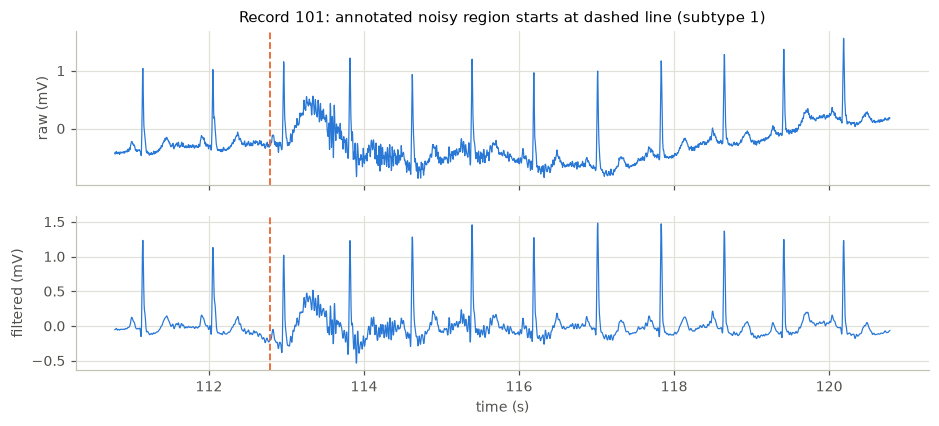

In [12]:
# Naturally noisy regions: signal-quality annotations ('~'). WFDB convention for the subtype field:
# bit k = signal k noisy, bit k+4 = signal k unreadable, -1 = all signals unreadable, 0 = clean again.
quality = []
for r in DS1:
    ann = wfdb.rdann(str(MITDB / str(r)), "atr")
    ch = wfdb.rdheader(str(MITDB / str(r))).sig_name.index(LEAD)
    for s, sym, sub in zip(ann.sample, ann.symbol, ann.subtype):
        if sym == "~":
            sub = int(sub)
            quality.append({"record": r, "sample": s, "subtype": sub,
                            "noisy": sub > 0 and bool(sub & (1 << ch)),
                            "unreadable": sub == -1 or (sub > 0 and bool(sub & (1 << (ch + 4))))})
quality = pd.DataFrame(quality)
noisy_marks = quality[quality.noisy | quality.unreadable]
print(f"'~' quality annotations in DS1: {len(quality)}, marking {LEAD} noisy: {int(quality.noisy.sum())}, "
      f"unreadable: {int(quality.unreadable.sum())}")
print("Noisy/unreadable marks per record:", noisy_marks.groupby("record").size().to_dict())

if len(noisy_marks):
    r, s = noisy_marks.iloc[0][["record", "sample"]]
    x, xf, samples, symbols = filtered_ds1[int(r)]
    seg = slice(max(0, s - 2 * FS), s + 8 * FS)
    t = np.arange(seg.start, seg.stop) / FS
    fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
    axes[0].plot(t, x[seg], color=CLASS_COLORS["N"], lw=0.8)
    axes[1].plot(t, xf[seg], color=CLASS_COLORS["N"], lw=0.8)
    for ax in axes:
        ax.axvline(s / FS, color=CLASS_COLORS["S"], lw=1.2, ls="--")
    axes[0].set_ylabel("raw (mV)")
    axes[1].set_ylabel("filtered (mV)")
    axes[1].set_xlabel("time (s)")
    axes[0].set_title(f"Record {int(r)}: annotated noisy region starts at dashed line (subtype {noisy_marks.iloc[0].subtype})")
    save(fig, "natural_noise_example")

## 2.4 Data quality

In [13]:
# Missing data, flat-line segments, ADC saturation and artifact/quality annotations for every used record.
rows = []
for r in ALL:
    rec = wfdb.rdrecord(str(MITDB / str(r)), physical=False)
    ch = rec.sig_name.index(LEAD)
    d = rec.d_signal[:, ch]
    x = rec.p_signal[:, ch] if rec.p_signal is not None else (d - rec.baseline[ch]) / rec.adc_gain[ch]
    blocks = x[: len(x) // FS * FS].reshape(-1, FS)
    ann = wfdb.rdann(str(MITDB / str(r)), "atr")
    sym = np.array(ann.symbol)
    rows.append({
        "record": r, "split": record_stats.set_index("record").split[r],
        "nan_samples": int(np.isnan(x).sum()),
        "flat_seconds": int((blocks.std(axis=1) < 0.01).sum()),
        "saturated_samples": int(((d <= d.min()) | (d >= d.max())).sum()) if d.max() - d.min() >= 2 ** rec.adc_res[ch] - 2 else 0,
        "adc_min": int(d.min()), "adc_max": int(d.max()),
        "artifact_marks_|": int((sym == "|").sum()), "quality_changes_~": int((sym == "~").sum()),
        "excluded_beats": int(record_stats.set_index("record").excluded_beats[r]),
    })
quality_df = pd.DataFrame(rows)
quality_df.to_csv(STATS / "data_quality.csv", index=False)
print("Total NaN samples:", quality_df.nan_samples.sum(), "| records with flat seconds:",
      int((quality_df.flat_seconds > 0).sum()), "| records touching ADC limits:", int((quality_df.saturated_samples > 0).sum()))
quality_df

Total NaN samples: 0 | records with flat seconds: 0 | records touching ADC limits: 1


,record,split,nan_samples,flat_seconds,saturated_samples,adc_min,adc_max,artifact_marks_|,quality_changes_~,excluded_beats
0,100,test,0,0,0,481,1311,0,0,0
1,101,train,0,0,0,389,1508,4,4,2
2,103,test,0,0,0,502,1649,0,6,0
3,105,test,0,0,0,281,1624,30,88,5
4,106,train,0,0,0,611,1538,0,30,0
5,108,train,0,0,0,417,1497,8,41,0
6,109,val,0,0,0,385,1650,0,2,0
7,111,test,0,0,0,460,1499,0,8,0
8,112,train,0,0,0,497,1188,0,10,0
9,113,test,0,0,0,779,1534,0,0,0


,record,baseline_wander_ratio,high_freq_ratio
2,108,1.9376,0.0096
17,209,0.2534,0.0094
0,101,0.2813,0.0075
19,220,0.0366,0.0072
18,215,0.0566,0.0058
1,106,0.0710,0.0048
14,205,0.1154,0.0042
6,115,0.3911,0.0040


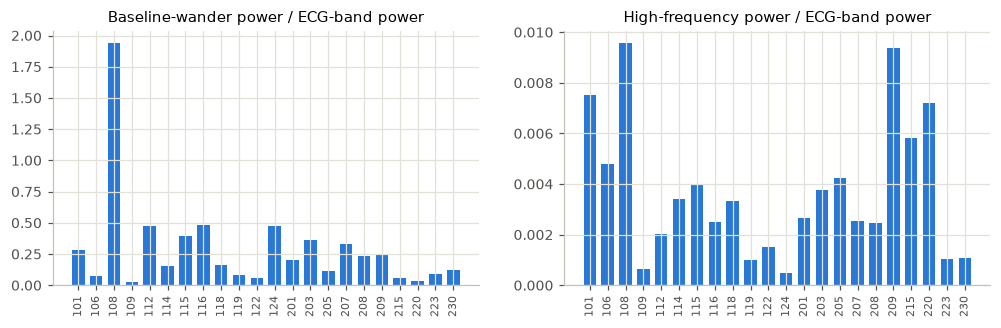

In [14]:
# Noise-level proxies per DS1 record: baseline-wander (<0.5 Hz) and high-frequency (>40 Hz) power relative to ECG band power
rows = []
lo = sps.butter(4, 0.5, btype="lowpass", fs=FS, output="sos")
hi = sps.butter(4, 40.0, btype="highpass", fs=FS, output="sos")
for r, (x, xf, _, _) in filtered_ds1.items():
    rows.append({
        "record": r,
        "baseline_wander_ratio": sps.sosfiltfilt(lo, x - x.mean()).var() / xf.var(),
        "high_freq_ratio": sps.sosfiltfilt(hi, x).var() / xf.var(),
    })
noise_proxy = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 3), sharex=True)
xs = np.arange(len(noise_proxy))
for ax, col, title in zip(axes, ["baseline_wander_ratio", "high_freq_ratio"],
                          ["Baseline-wander power / ECG-band power", "High-frequency power / ECG-band power"]):
    ax.bar(xs, noise_proxy[col], color=CLASS_COLORS["N"], width=0.7)
    ax.set_xticks(xs, noise_proxy.record, rotation=90, fontsize=7)
    ax.set_title(title)
save(fig, "noise_proxies_ds1")
noise_proxy.round(4).sort_values("high_freq_ratio", ascending=False).head(8)

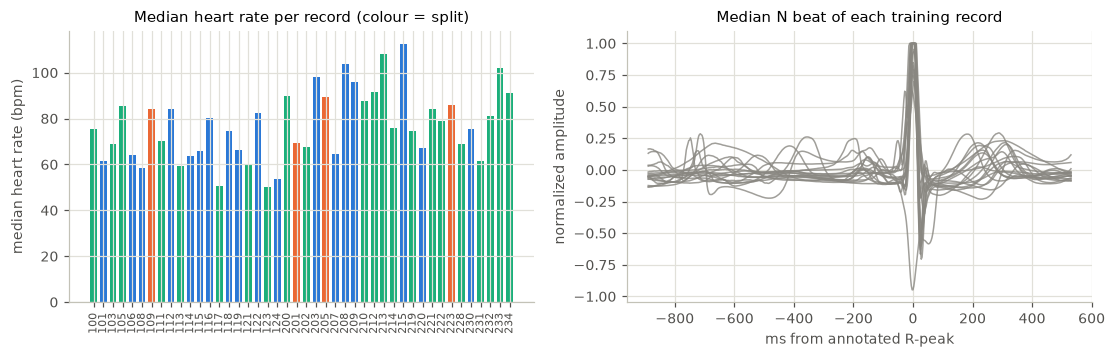

In [15]:
# Differences between recordings: heart rate, amplitude and normal-beat morphology (DS1 training records)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.2))
rs = record_stats.sort_values("record")
xs = np.arange(len(rs))
axes[0].bar(xs, 60 / rs.median_rr_s, color=[SPLIT_COLORS[s] for s in rs.split], width=0.7)
axes[0].set_xticks(xs, rs.record, rotation=90, fontsize=7)
axes[0].set_ylabel("median heart rate (bpm)")
axes[0].set_title("Median heart rate per record (colour = split)")

for r in SPLITS["train"]:
    idx = np.flatnonzero((train["record"] == r) & (train["y"] == 0))
    if len(idx) > 50:
        axes[1].plot(t_ms, np.median(X[idx], axis=0), lw=1, alpha=0.8, color=MUTED)
axes[1].set_xlabel("ms from annotated R-peak")
axes[1].set_ylabel("normalized amplitude")
axes[1].set_title("Median N beat of each training record")
save(fig, "record_differences")

Channel pairs: {'MLII / V1': 38, 'MLII / V5': 2, 'MLII / V2': 2, 'V5 / MLII': 1, 'MLII / V4': 1}
Records where MLII is not channel 0: [114]


,record,leads,correlation
0,101,MLII / V1,-0.338
1,106,MLII / V1,0.141
2,108,MLII / V1,-0.356
3,109,MLII / V1,-0.792
4,112,MLII / V1,-0.271
5,114,V5 / MLII,0.139
6,115,MLII / V1,-0.158
7,116,MLII / V1,-0.628
8,118,MLII / V1,0.090
9,119,MLII / V1,-0.829


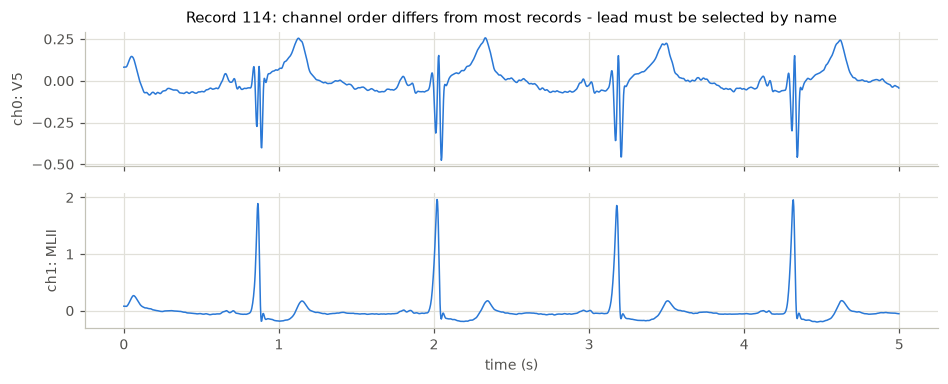

In [16]:
# Differences between ECG channels
print("Channel pairs:", (headers.channel_0 + " / " + headers.channel_1).value_counts().to_dict())
print("Records where MLII is not channel 0:", headers.loc[headers.channel_0 != LEAD, "record"].tolist())

r = 114  # DS1 record with MLII on channel 1
rec = wfdb.rdrecord(str(MITDB / str(r)))
seg = slice(0, 5 * FS)
t = np.arange(seg.stop) / FS
fig, axes = plt.subplots(2, 1, figsize=(10, 3.5), sharex=True)
for ax, ch in zip(axes, range(rec.n_sig)):
    ax.plot(t, preprocess_signal(rec.p_signal[:, ch], FS, cfg)[seg], color=CLASS_COLORS["N"], lw=1)
    ax.set_ylabel(f"ch{ch}: {rec.sig_name[ch]}")
axes[0].set_title(f"Record {r}: channel order differs from most records - lead must be selected by name")
axes[1].set_xlabel("time (s)")
save(fig, "channel_differences")

corr = []
for r in DS1:
    rec = wfdb.rdrecord(str(MITDB / str(r)))
    a, b = (preprocess_signal(rec.p_signal[:, i], FS, cfg) for i in range(2))
    corr.append({"record": r, "leads": " / ".join(rec.sig_name), "correlation": np.corrcoef(a, b)[0, 1]})
pd.DataFrame(corr).round(3)

## 2.5 Leakage analysis

Checks below are the programmatic part; the argument itself belongs in the report.

In [17]:
ds1, ds2 = set(cfg["splits"]["ds1"]), set(cfg["splits"]["ds2"])
print("DS1 and DS2 share records:", sorted(ds1 & ds2) or "none")
print("Train and validation share records:", sorted(set(SPLITS["train"]) & set(SPLITS["val"])) or "none")
print("Records per split:", {k: len(v) for k, v in SPLITS.items()})

# Records 201 and 202 come from the same subject (PhysioNet MIT-BIH directory) -> same person in DS1 and DS2.
for r in (201, 202):
    print(r, "in", "DS1" if r in ds1 else "DS2", "| header comment:", wfdb.rdheader(str(MITDB / str(r))).comments)

DS1 and DS2 share records: none
Train and validation share records: none
Records per split: {'train': 18, 'val': 4, 'test': 22}
201 in DS1 | header comment: ['68 M 1960 2851 x1', 'Digoxin, Hydrochlorthiazide, Inderal, KCl', 'The PVCs are uniform and late-cycle.  Junctional escape beats occur following', 'episodes of ventricular trigeminy.']
202 in DS2 | header comment: ['68 M 1960 2851 x1', 'Digoxin, Hydrochlorthiazide, Inderal, KCl', 'The PVCs are uniform and late-cycle.  This record was taken from the same', 'analog tape as record 201.']


## Summary of findings

*TODO (group): write the interpretation of each figure/table above - these points feed report sections 2.3-2.5
and the preprocessing decisions in section 3.*